
## Academic Integrity and Learning Statement

By submitting my work, I confirm that:

- The code, analysis, and documentation in this notebook are my own work and reflect my own understanding.
- I am prepared to explain all code and analysis included in this submission.

If I used assistance (e.g., AI tools, tutors, or other resources), I have:

- Clearly documented where and how external tools or resources were used in my solution.
- Included a copy of the interaction (e.g., AI conversation or tutoring notes) in an appendix.

I acknowledge that:

- I may be asked to explain any part of my code or analysis during evaluation.
- Misrepresenting assisted work as my own constitutes academic dishonesty and undermines my learning.


## D. EDA: Text data

The essential methods and skills for data analysis can vary from one data type to another. For instance, text data requires different manipulation techniques than numerical data. One example of text data in the Open Food database can be found in the ingredients_en column.

Your goal is to tokenize each product into its individual ingredients, i.e. your tokens are the separate ingredients. But first you need to clean and preprocess the text entries in this column.

    Start by printing and exploring several samples from the ingredients_en column. (Hint: It help to look for diverse samples that highlight different problems, e.g. look at some of the longest strings in this column)
    Identify and clearly state the main issues that you will need to address through text cleaning in order to ensure that your subsequent analyses provide reliable results. Then formulate and implement a strategy to address these cases and store the cleaned text in the column ingredients_en_cleaned.
    Be careful with text normalization:
        capitalization, e.g., “water” vs. “Water”
        punctuation, e.g., “water.” vs. “water”
        white spaces removal, e.g., “ water” vs. “water”
        special characters, e.g. “raw beef [soja sauce (with ble), …]”
    Print the full ingredient lists of some samples before and after text cleaning in order to verify that the issues you identified where indeed resolved.

By tokenizing the cleaned data into individual ingredients, answer the following questions:

    Which product has the longest ingredients list, i.e. the largest number of ingredients?
    Print the product name and its ingredient list.
    Which products has the shortest ingredients list, i.e. the fewest ingredients.
    Display multiple examples of product names and ingredients and comment on what these products may have in common.
    What are the most frequent ingredients across all products?
    Provide a table and choose an appropriate method to visualize your findings.


In [3]:
# Start by printing and exploring several samples from the ingredients_en column. 
# Hint: It help to look for diverse samples that highlight different problems
# e.g. look at some of the longest strings in this column
import pandas as pd

df = pd.read_csv("data_clean.csv")

# save list of ingredients: 
ingredients = df["ingredients_en"]

# have a look of unique values (if there are repetitions in some of the values). 
ingredients.value_counts().head(10)


ingredient_missing                                                                                                                           22723
SEMOLINA (WHEAT), DURUM FLOUR (WHEAT), NIACIN, FERROUS SULFATE (IRON), THIAMIN MONONITRATE, RIBOFLAVIN, FOLIC ACID.                            301
GREEN BEANS, WATER, SALT.                                                                                                                      229
HONEY.                                                                                                                                         213
TOMATO CONCENTRATE, HIGH FRUCTOSE CORN SYRUP, DISTILLED VINEGAR, CORN SYRUP, SALT, LESS THAN 2% OF: SPICE, ONION POWDER, NATURAL FLAVORS.      198
CORN.                                                                                                                                          177
SUGAR.                                                                                                                

#### Comments
The first thing we observe is that a lot of the entries don't have ingredients listed (and are listed as ingredient_missing). We can also already see that some of the lines are capitalized while others aren't, and that some end with a "." while others don't. Ingredients seem to be separated by ",". We should be careful about the line "Less than 2% of" that appears frequently. 

In [4]:
# Look at some of the longer entries in the list

# return the index of the 5 longest entries
long_index = ingredients.str.len().sort_values().tail(5).index

print(ingredients[long_index[1]])

CLASSIC FUDGE: BROWNIE MIX (SUGAR, ENRICHED WHEAT FLOUR [WHEAT FLOUR, NIACIN, REDUCED IRON, THIAMINE MONONITRATE, RIBOFLAVIN, FOLIC ACID], COCOA [PROCESSED WITH ALKALI], DRIED EGG WHITES, CORN SYRUP SOLIDS, CONTAINS 2% OR LESS OF THE FOLLOWING: SOYBEAN OIL, SALT, CORN STARCH, LEAVENING [SODIUM BICARBONATE, SODIUM ACID PYROPHOSPHATE], NATURAL FLAVOR, NONFAT DRY MILK, SOY FLOUR), POWDERED SUGAR (SUGAR, CORNSTARCH), MARGARINE (PALM OIL, WATER, SALT, MONO- AND DIGLYCERIDES, NATURAL BUTTER FLAVOR, CITRIC ACID [PRESERVATIVE], BETA-CAROTENE [COLOR], VITAMIN A PALMITATE), FUDGE SAUCE (CORN SYRUP, SWEETENED CONDENSED MILK [MILK, SUGAR], WATER, PALM OIL, SUGAR, COCOA [PROCESSED WITH ALKALI], CONTAINS LESS THAN 2% OF THE FOLLOWING: CARRAGEENAN, CULTURED DEXTROSE, MODIFIED FOOD STARCH, SALT), COCOA (PROCESSED WITH ALKALI), SOYBEAN OIL, CORN SYRUP, NONFAT MILK POWDER, NATURAL FLAVOR, DARK COCOA POWDER (PROCESSED WITH ALKALI), GUM BLEND (GUM ARABIC, XANTHAN GUM, MODIFIED GUM ARABIC), MODIFIED FOOD S

#### Comments
We directly see several problems. 
- the ingredient list contains a lot of information in between "()" or "[]". We will need to decide what we want to do with this information. In some cases, this information is clearly not an ingredient (processed with alkali, preservative). In a lot of other cases, it seems like it is a subdivision of the main ingredient. 
- some ingredients appear several times (such as "sugar"). We will need to remove duplicates
- This entry is entirely capitalized. This is not the case for all entries. 
- There's the line "Contains less than 2% of the following:" that will need to be removed. 
- There's also a variation of this with "contains 2% or less of ..."
- Some of the ingredients are also separated by ":" (Classic Fudge: Brownie Mix are likely two separate ingredients). 

In [4]:
# Let's look at another entry
print(ingredients[long_index[3]])

WATER, POWDERED SUGAR (SUGAR, CORN STARCH), CHOCOLATE ICING (SUGAR, WATER, PALM OIL, CORN SYRUP, COCOA PROCESSED WITH ALKALI, CONTAINS 2% OR LESS OF: CARAMEL COLOR, CELLULOSE GUM, MONO- AND DIGLYCERIDES, NATURAL AND ARTIFICIAL FLAVOR, POLYSORBATE 60, POTASSIUM SORBATE [PRESERVATIVE], SORBIC ACID [PRESERVATIVE], SALT, SOY LECITHIN, SOYBEAN OIL, SULFITES, XANTHAN GUM), CARROT CAKE (SUGAR, ENRICHED WHEAT FLOUR BLEACHED [FLOUR, NIACIN, REDUCED IRON, THIAMINE MONONITRATE, RIBOFLAVIN, FOLIC ACID], SOYBEAN OIL, DEXTROSE, CARROTS, FOOD STARCH-MODIFIED, DRIED EGG YOLK, LEAVENING [BAKING SODA, SODIUM ACID PYROPHOSPHATE, SODIUM ALUMINUM PHOSPHATE, ALUMINUM SULFATE], DRIED EGG WHITES, NATURAL AND ARTIFICIAL FLAVOR, SALT, XANTHAN GUM, PROPYLENE GLYCOL, GUAR GUM, WATER, CARAMEL COLOR, CORN SYRUP, POLYSORBATE 80, GLYCERIN, CORN STARCH, CORN OIL, WHEAT STARCH, BETA CAROTENE [COLOR], TOCOPHEROLS [PRESERVATIVE], CITRIC ACID [PRESERVATIVE], SILICON DIOXIDE), RED VELVET CAKE (SUGAR, ENRICHED BLEACHED WHEA

#### Comments

Here we observe a entry that looks quite different. Some observations are : 
- This entry contains a mix of capitalized and non capitalized ingredients. 
- Here some of the ingredients are also separated by ":" 
- Some ingredients are preceeded with "contains" or "May contains traces of" that will need to be removed as it is not an ingredient. 
- We also see here the sentence "Contains 2% or less of:"
- Other problematic sentences are CONTAINS WHEAT, COCONUT, AND SOY INGREDIENTS. here we will need to remove the "and"

We will start by creating a function to adress some of these issues. The first issues we will adress are:
- uncapitalize everything
- replace ")" and ")," and by ","
- replace "]" and "]," and by ","
- replace ":" by ","
- replace " (" and " [" by ","
- remove final "." and ","
- remove all spaces after a comma

In [5]:
# write a function to clean the data

def transform(s):
    s = s.str.lower()
    # remove numbers in parenthesis and % in general
    s = s.str.replace(r"\(\d+%\)", "", regex=True)
    s = s.str.replace(r"\d+%", "", regex=True)
    s = s.str.replace(r"\),?", ",", regex=True)
    s = s.str.replace(r"\],?", ",", regex=True)
    s = s.str.replace(r"\s\(", ", ", regex=True)
    s = s.str.replace(r"\s\[", ", ", regex=True)
    s = s.str.replace(":", ",") 
    s = s.str.rstrip(",.")
    s = s.str.replace(r",\s+", ",", regex=True)
    s = s.str.replace(r"\s+,", ",", regex=True)
    s = s.str.replace(r",,", ",", regex=True)
    return s    


In [6]:
ingredients = transform(ingredients)

In [7]:
# Look at some of the longer entries in the new list

# return the index of the 5 longest entries
long_index = ingredients.str.len().sort_values().tail(5).index

print(ingredients[long_index[1]])

classic fudge,brownie mix,sugar,enriched wheat flour,wheat flour,niacin,reduced iron,thiamine mononitrate,riboflavin,folic acid,cocoa,processed with alkali,dried egg whites,corn syrup solids,contains  or less of the following,soybean oil,salt,corn starch,leavening,sodium bicarbonate,sodium acid pyrophosphate,natural flavor,nonfat dry milk,soy flour,powdered sugar,sugar,cornstarch,margarine,palm oil,water,salt,mono- and diglycerides,natural butter flavor,citric acid,preservative,beta-carotene,color,vitamin a palmitate,fudge sauce,corn syrup,sweetened condensed milk,milk,sugar,water,palm oil,sugar,cocoa,processed with alkali,contains less than  of the following,carrageenan,cultured dextrose,modified food starch,salt,cocoa,processed with alkali,soybean oil,corn syrup,nonfat milk powder,natural flavor,dark cocoa powder,processed with alkali,gum blend,gum arabic,xanthan gum,modified gum arabic,modified food starch. cookies & cream,brownie mix,sugar,enriched wheat flour,wheat flour,niacin,re

#### Comments

the data already looks much cleaner. We will now split it, and keep only the ingredients that are ingredients:
- they shouldn't contain the word "less"
- they shouldn't contain the word "contain"
- they shouldn't contain the word "alkali"
- we should also remove all duplicates

In [8]:
import re
def tokenize(ingredient_list):
    ingredient_list = ingredient_list.split(",")
    
    # remove entries that contain "less", "contain" or "alkali" which are some thing that I observed to occur often
    ingredient_list = [item for item in ingredient_list if not re.search(r"less", item)]
    ingredient_list = [item for item in ingredient_list if not re.search(r"contain", item)]
    ingredient_list = [item for item in ingredient_list if not re.search(r"alkali", item)]
    
    # remove duplicates
    seen = []
    result = []
    for item in ingredient_list:
        if item not in seen:
            seen.append(item)
            result.append(item)             
    return ", ".join(result)

ingredients_cleaned = ingredients.apply(tokenize)

In [9]:
print(ingredients_cleaned)

0                                        ingredient_missing
1         organic dates, organic cocoa paste, organic wh...
2         organic dates, organic apples, organic whole m...
3         filtered water, freshly squeezed ginger root j...
4                                       apples - elderberry
                                ...                        
223214                                   ingredient_missing
223215                                   ingredient_missing
223216                                   ingredient_missing
223217                                   ingredient_missing
223218                                   ingredient_missing
Name: ingredients_en, Length: 223219, dtype: object


#### Comments 
this looks much better, let's add this column back to the original data frame

In [10]:
# add the column ingredient cleaned to the data frame:

df["ingredients_cleaned"] = ingredients_cleaned
df["ingredients_cleaned"].head()

0                                   ingredient_missing
1    organic dates, organic cocoa paste, organic wh...
2    organic dates, organic apples, organic whole m...
3    filtered water, freshly squeezed ginger root j...
4                                  apples - elderberry
Name: ingredients_cleaned, dtype: object

In [13]:
# Now we can have a look at what the longest and shortest entries are:

# the product with the longest entry is:
print("the product with the longest ingredients list is:", df.loc[df["ingredients_cleaned"].str.len().sort_values().tail(1).index[0], "product_name_en"])

# the product with the shortest entry is:
# here we need to be careful because some of the entries are "ingredient_missing" or are empty
valid_ingredients = df.loc[
    (df["ingredients_cleaned"] != "ingredient_missing") &
    (df["ingredients_cleaned"] != ""),
    "ingredients_cleaned"
]
# Find the index of the shortest string
shortest = valid_ingredients.str.len().sort_values().head(20)
print("the 10 products with the shortest ingredients list are:")
for ind in shortest.index:
    print(df.loc[ind, "product_name_en"])
    print("ingredient list :", df.loc[ind, "ingredients_cleaned"])

the product with the longest ingredients list is: FANNIE MAY, MILK AND DARK ASSORTED CHOCOLATES
the 10 products with the shortest ingredients list are:
Mello Yello Can, 16 fl oz
ingredient list : wa
Hubert's Lemonade Watermelon Bottle, 18 fl oz
ingredient list : er
WHOLE GROUND SOY FLOUR 35% PROTEIN
ingredient list : soy
5 OZ COD LOINS
ingredient list : cod
BACARDI CARTA ORO SUPERIOR GOLD RUM
ingredient list : rum
Fanta Orange Soda Bottle, 12 fl oz
ingredient list : wat
PG Tips Free the Fresh Taste
ingredient list : tea
BONELESS & SKINLESS LOINS COD
ingredient list : cod
16/32 OZ S/P COD FILLETS
ingredient list : cod
WILD CAUGHT PACIFIC COD
ingredient list : cod
FULL CIROLE, ALL NATURAL ALASKA WILD COT FILLETS
ingredient list : cod
H&G BLACK COD
ingredient list : cod
8/16 OZ COD FILLETS
ingredient list : cod
8/10 OZ COD FILLET
ingredient list : cod
WILD ALASKA COD FILLETS
ingredient list : cod
Diet Coke Bottle, 8.5 fl oz
ingredient list : wat
16/32 OZ S/P COD FILLETS
ingredient list : 

#### Comments
we see that most items with a small ingredient list are either non-transformed (e.g. cod, rum, tea) or they contain mistakes (what is ---, or "er" or "wa"). We could probably try to adress these mistakes by filtering out words that are english, but this is likely very complicated for such an ingredient list that contains a lot of scientific words that probably don't exist in a common english dictionary. 

On the other hand, items with a very long list of ingredients are often highly transformed. 

In [14]:
# Now summarize what the most frequent ingredients are

# First concatenate all ingredients from all entries together
ingredient_list = df.loc[
    (df["ingredients_cleaned"] != "ingredient_missing") &
    (df["ingredients_cleaned"] != ""),
    "ingredients_cleaned"].str.cat(sep=",")

In [15]:
# Then use the counter function to count the most frequent tokens.
from collections import Counter

# Print top-25 most frequent tokens in ingredient list
frequent_ingredient = pd.DataFrame(Counter(ingredient_list.split(", ")).most_common(25), columns=("ingredient", "count")).set_index("ingredient")

Text(0.5, 0, 'count')

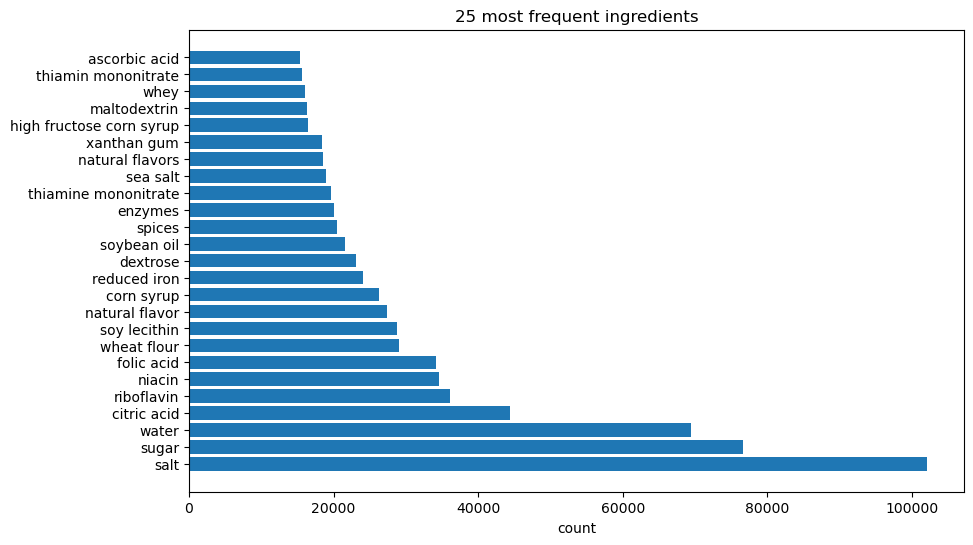

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.barh(frequent_ingredient.index, frequent_ingredient["count"])
plt.title("25 most frequent ingredients")
plt.xlabel("count")

#### Comments
We observe that salt and sugar are some of the most common ingredients, as expected. Interestingly, there are also some other ingredients that you mostly find in transformed food items, such as citric acid, ascorbic acid, natural flavor, corn syrup, etc. that pop up fairly often